In [65]:
import sys, ast
from pathlib import Path
import importlib

root = Path.cwd()
while not (root / "Models").is_dir():
    root = root.parent
sys.path.insert(0, str(root))

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

KeyError: 'logMmin'

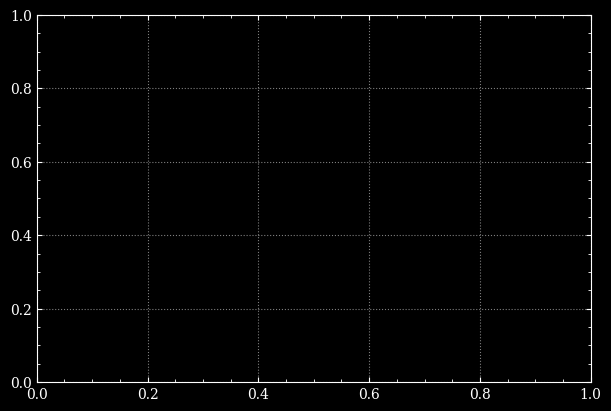

In [68]:
plist = ['Zehavi2005', 'Zheng2005', 'More2015', 'Yuan2024', 'Kusiak2022', 'Kou2023', 'Hadzhiyska2025B', 'Hadzhiyska2026']
# get to linke2022 later
for p in plist: 
    globals()[p] = importlib.import_module(f".{p}", package=f"Models.Papers.{p}")
    importlib.reload(globals()[p])


logM = np.linspace(10, 15, 100)

fig, ax = plt.subplots(1, 1, figsize=(6, 4), layout='constrained')

for paper in [globals()[p].HOD for p in plist]:
    model = paper(logM=logM)
    ax.plot(logM, model.Ncen(), label=f"{paper.__module__} Ncen")